<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/W2_Prism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pd.set_option("display.max_columns", None)

# Better plot size
plt.rcParams["figure.figsize"] = (15,5)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/PRISM/raw_data/TCS.NS.csv")

In [ ]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2019-01-01,1561.000366,1566.906991,1546.397737,1555.421809,1094883
1,2019-01-02,1577.817871,1586.964918,1558.703207,1562.805058,2100463
2,2019-01-03,1558.661987,1595.578638,1553.042473,1574.290076,2611668
3,2019-01-04,1539.711914,1559.687910,1510.301660,1558.703506,4280862
4,2019-01-07,1556.980835,1565.922891,1543.116557,1551.976596,1856423


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 0 to 1480
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1481 non-null   datetime64[ns]
 1   Close   1481 non-null   float64       
 2   High    1481 non-null   float64       
 3   Low     1481 non-null   float64       
 4   Open    1481 non-null   float64       
 5   Volume  1481 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 69.6 KB


In [ ]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2019-01-01,1561.000366,1566.906991,1546.397737,1555.421809,1094883
1,2019-01-02,1577.817871,1586.964918,1558.703207,1562.805058,2100463
2,2019-01-03,1558.661987,1595.578638,1553.042473,1574.290076,2611668
3,2019-01-04,1539.711914,1559.687910,1510.301660,1558.703506,4280862
4,2019-01-07,1556.980835,1565.922891,1543.116557,1551.976596,1856423


In [ ]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,1481,1481.000000,1481.000000,1481.000000,1481.000000,1.481000e+03
mean,2021-12-31 09:47:16.731937792,2751.234894,2778.450892,2724.831646,2752.136331,2.745963e+06
min,2019-01-01 00:00:00,1403.242676,1445.348082,1282.136856,1337.511880,1.548950e+05
25%,2020-07-08 00:00:00,1901.626465,1923.109714,1878.140557,1900.743953,1.711510e+06
50%,2021-12-30 00:00:00,2889.345703,2914.740785,2863.073160,2889.963693,2.316539e+06
75%,2023-06-28 00:00:00,3231.117920,3254.525377,3205.212396,3234.931600,3.224657e+06
max,2024-12-31 00:00:00,4253.906738,4289.871692,4214.905946,4274.691846,1.983933e+07
std,NaN,735.664118,739.792078,731.702854,735.225574,1.660880e+06


In [ ]:
df.shape

(1481, 6)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.dropna()

In [ ]:
df["return"] = df["Close"].pct_change()

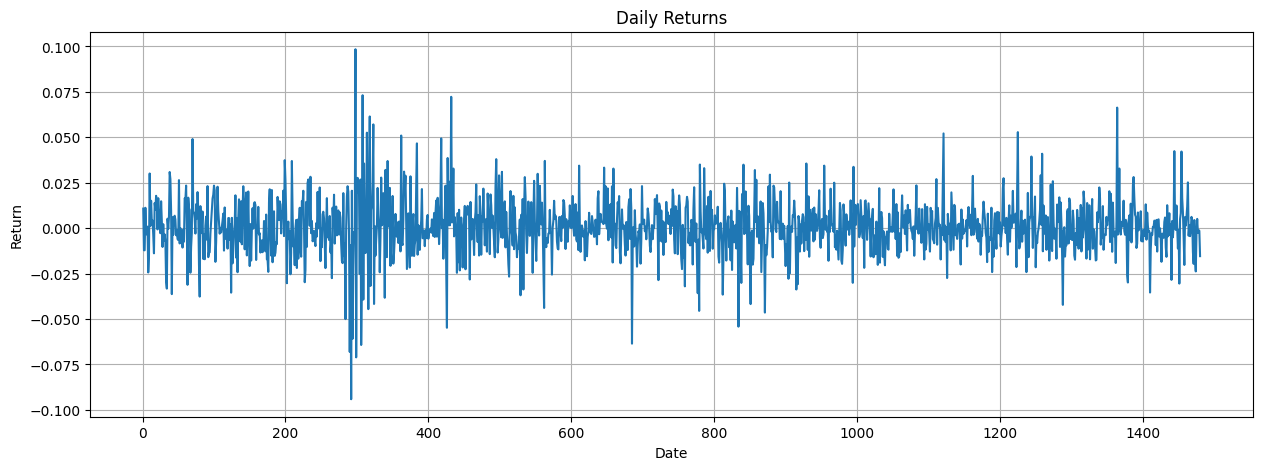

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["return"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

In [ ]:
df["log_return"] = np.log(      #ts is the most imp concept of how to calculate returns
    df["Close"] /
    df["Close"].shift(1)
)

In [ ]:
df[["Close","return"]].head(10)

,Close,return
0,1561.000366,NaN
1,1577.817871,0.010774
2,1558.661987,-0.012141
3,1539.711914,-0.012158
4,1556.980835,0.011216
5,1553.411865,-0.002292
6,1547.997559,-0.003485
7,1549.310181,0.000848
8,1511.573120,-0.024357
9,1487.536255,-0.015902


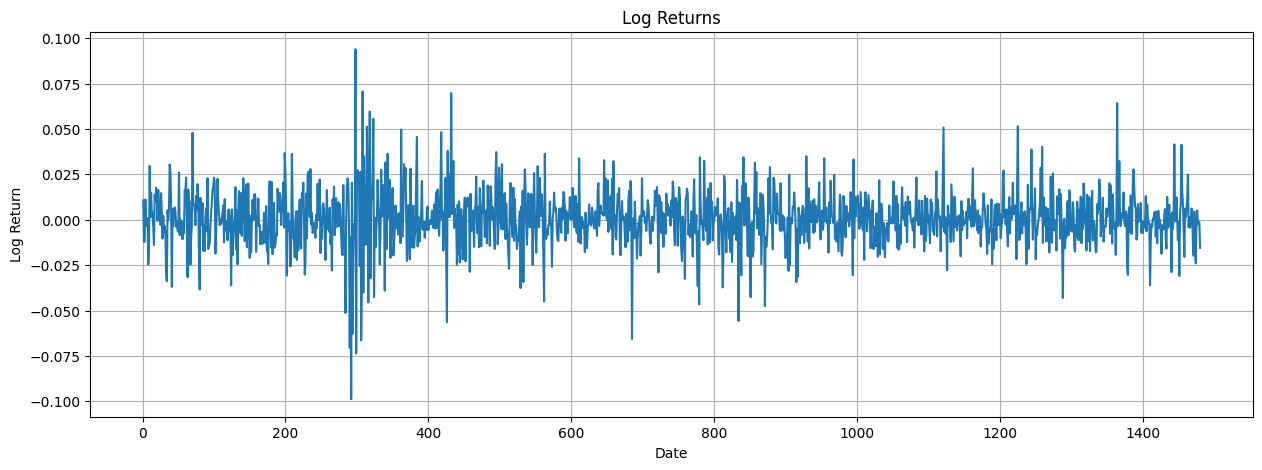

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["log_return"])
plt.title("Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

In [ ]:
print(df[["Close", "return", "log_return"]].head(10))

         Close    return  log_return
0  1561.000366       NaN         NaN
1  1577.817871  0.010774    0.010716
2  1558.661987 -0.012141   -0.012215
3  1539.711914 -0.012158   -0.012232
4  1556.980835  0.011216    0.011153
5  1553.411865 -0.002292   -0.002295
6  1547.997559 -0.003485   -0.003492
7  1549.310181  0.000848    0.000848
8  1511.573120 -0.024357   -0.024659
9  1487.536255 -0.015902   -0.016030


In [ ]:
print(df[["return", "log_return"]].describe())

            return   log_return
count  1480.000000  1480.000000
mean      0.000724     0.000607
std       0.015253     0.015250
min      -0.094104    -0.098830
25%      -0.006960    -0.006984
50%       0.000519     0.000518
75%       0.008536     0.008500
max       0.098451     0.093901


In [ ]:
df["MA5"] = df["Close"].rolling(window=5).mean()

# 10-Day Moving Average
df["MA10"] = df["Close"].rolling(window=10).mean()

# 20-Day Moving Average
df["MA20"] = df["Close"].rolling(window=20).mean()

In [ ]:
# Check
df[["Close", "MA5", "MA10", "MA20"]].head(25)

,Close,MA5,MA10,MA20
0,1561.000366,NaN,NaN,NaN
1,1577.817871,NaN,NaN,NaN
2,1558.661987,NaN,NaN,NaN
3,1539.711914,NaN,NaN,NaN
4,1556.980835,1558.834595,NaN,NaN
5,1553.411865,1557.316895,NaN,NaN
6,1547.997559,1551.352832,NaN,NaN
7,1549.310181,1549.482471,NaN,NaN
8,1511.573120,1543.854712,NaN,NaN
9,1487.536255,1529.965796,1544.400195,NaN


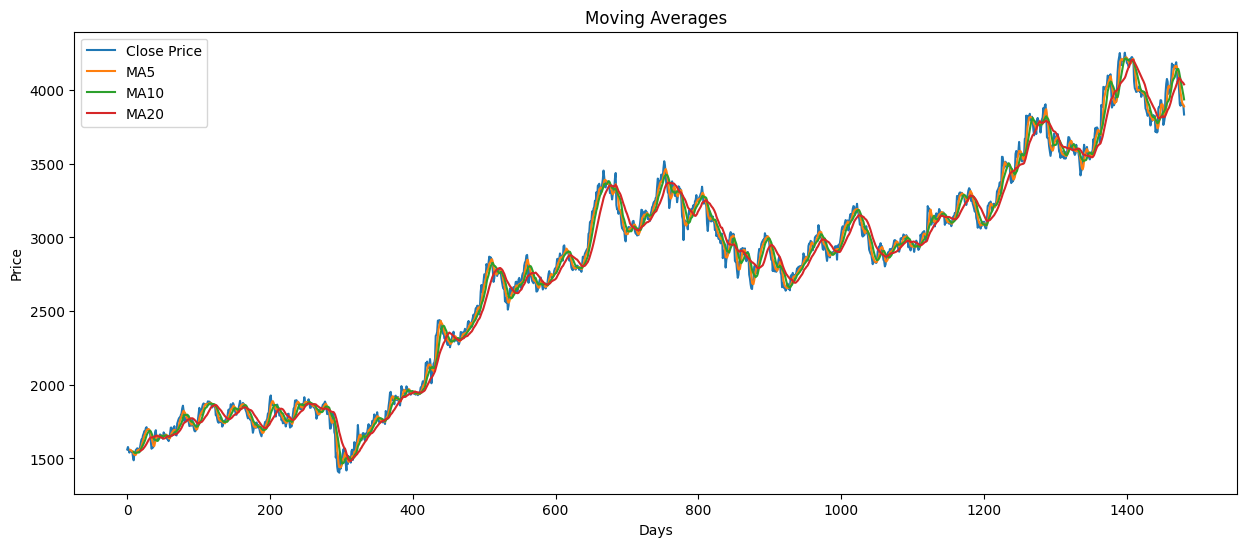

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(df["Close"], label="Close Price")
plt.plot(df["MA5"], label="MA5")
plt.plot(df["MA10"], label="MA10")
plt.plot(df["MA20"], label="MA20")
plt.title("Moving Averages")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
# 20-Day Rolling Volatility
df["Volatility"] = df["return"].rolling(window=20).std()

# Check
df[["return", "Volatility"]].head(25)

,return,Volatility
0,NaN,NaN
1,0.010774,NaN
2,-0.012141,NaN
3,-0.012158,NaN
4,0.011216,NaN
5,-0.002292,NaN
6,-0.003485,NaN
7,0.000848,NaN
8,-0.024357,NaN
9,-0.015902,NaN


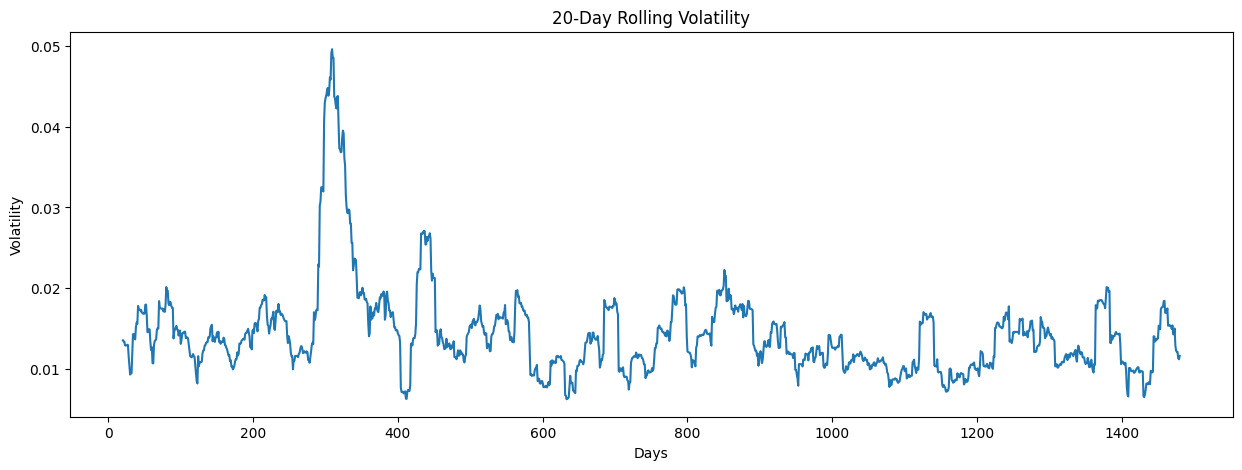

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df["Volatility"])
plt.title("20-Day Rolling Volatility")
plt.xlabel("Days")
plt.ylabel("Volatility")
plt.show()

In [ ]:
df["Volume_Change"] = df["Volume"].pct_change()
df["Volume_MA20"] = df["Volume"].rolling(window=20).mean()
df[["Volume", "Volume_Change", "Volume_MA20"]].head(25)

,Volume,Volume_Change,Volume_MA20
0,1094883,NaN,NaN
1,2100463,0.918436,NaN
2,2611668,0.243377,NaN
3,4280862,0.639129,NaN
4,1856423,-0.566344,NaN
5,1691756,-0.088701,NaN
6,2414376,0.427142,NaN
7,3053461,0.264700,NaN
8,9209862,2.016204,NaN
9,3615370,-0.607446,NaN


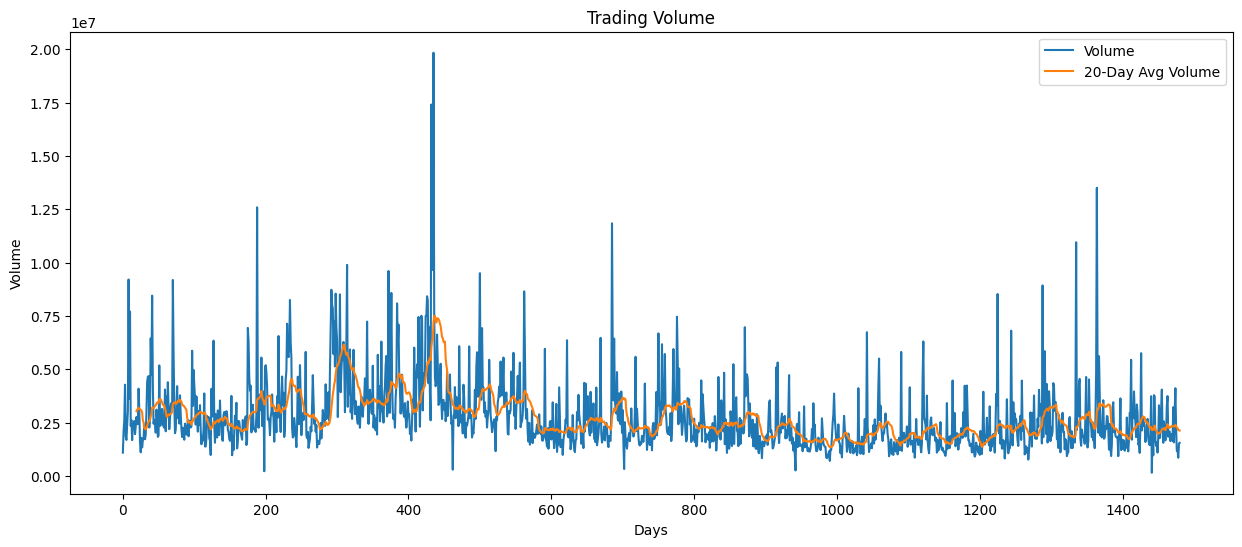

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(df["Volume"], label="Volume")
plt.plot(df["Volume_MA20"], label="20-Day Avg Volume")
plt.title("Trading Volume")
plt.xlabel("Days")
plt.ylabel("Volume")
plt.legend()
plt.show()

In [ ]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'return',
       'log_return', 'MA5', 'MA10', 'MA20', 'Volatility', 'Volume_Change',
       'Volume_MA20'],
      dtype='object')


In [ ]:
df.head(25)

,Date,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20
0,2019-01-01,1561.000366,1566.906991,1546.397737,1555.421809,1094883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02,1577.817871,1586.964918,1558.703207,1562.805058,2100463,0.010774,0.010716,NaN,NaN,NaN,NaN,0.918436,NaN
2,2019-01-03,1558.661987,1595.578638,1553.042473,1574.290076,2611668,-0.012141,-0.012215,NaN,NaN,NaN,NaN,0.243377,NaN
3,2019-01-04,1539.711914,1559.687910,1510.301660,1558.703506,4280862,-0.012158,-0.012232,NaN,NaN,NaN,NaN,0.639129,NaN
4,2019-01-07,1556.980835,1565.922891,1543.116557,1551.976596,1856423,0.011216,0.011153,1558.834595,NaN,NaN,NaN,-0.566344,NaN
5,2019-01-08,1553.411865,1563.953601,1545.003072,1563.133231,1691756,-0.002292,-0.002295,1557.316895,NaN,NaN,NaN,-0.088701,NaN
6,2019-01-09,1547.997559,1574.290464,1531.385062,1564.774190,2414376,-0.003485,-0.003492,1551.352832,NaN,NaN,NaN,0.427142,NaN
7,2019-01-10,1549.310181,1562.805230,1535.815031,1550.499677,3053461,0.000848,0.000848,1549.482471,NaN,NaN,NaN,0.264700,NaN
8,2019-01-11,1511.573120,1538.194092,1505.379285,1534.092242,9209862,-0.024357,-0.024659,1543.854712,NaN,NaN,NaN,2.016204,NaN
9,2019-01-14,1487.536255,1518.505230,1484.870052,1517.684860,3615370,-0.015902,-0.016030,1529.965796,1544.400195,NaN,NaN,-0.607446,NaN


In [ ]:
import yfinance as yf

nifty = yf.download(
    "^NSEI",
    start="2019-01-01",
    end="2025-01-01",
    auto_adjust=False,
    multi_level_index=False
)

nifty.reset_index(inplace=True)

nifty.to_csv(
    "/content/drive/MyDrive/PRISM/raw_data/^NSEI.csv",
    index=False
)

[*********************100%***********************]  1 of 1 completed


In [ ]:
nifty = pd.read_csv("/content/drive/MyDrive/PRISM/raw_data/^NSEI.csv")

In [ ]:
nifty.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2019-01-02,10792.500000,10792.500000,10895.349609,10735.049805,10868.849609,309700
1,2019-01-03,10672.250000,10672.250000,10814.049805,10661.250000,10796.799805,286200
2,2019-01-04,10727.349609,10727.349609,10741.049805,10628.650391,10699.700195,296600
3,2019-01-07,10771.799805,10771.799805,10835.950195,10750.150391,10804.849609,269400
4,2019-01-08,10802.150391,10802.150391,10818.450195,10733.250000,10786.250000,277700


In [ ]:
nifty["Date"] = pd.to_datetime(nifty["Date"])

In [ ]:
print(nifty.dtypes)

Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object


In [ ]:
nifty["market_return"] = nifty["Close"].pct_change()

In [ ]:
nifty = nifty[["Date", "market_return"]]

In [ ]:
df = pd.merge(
    df,
    nifty,
    on="Date",
    how="inner"
)

In [ ]:
covariance = (
    df["return"]
    .rolling(60)
    .cov(df["market_return"])
)

variance = (
    df["market_return"]
    .rolling(60)
    .var()
)

df["beta"] = covariance / variance

In [ ]:
df[["return","market_return","beta"]].tail()

,return,market_return,beta
1473,0.005098,-0.001086,0.986705
1474,-0.002488,0.000950,0.983655
1475,-0.001019,0.002661,0.989639
1476,-0.001453,-0.007076,0.982379
1477,-0.015389,-0.000004,1.016132


In [ ]:
df["beta"].describe()

,beta
count,1418.000000
mean,0.712281
std,0.279787
min,-0.154954
25%,0.571876
50%,0.749854
75%,0.910398
max,1.298478


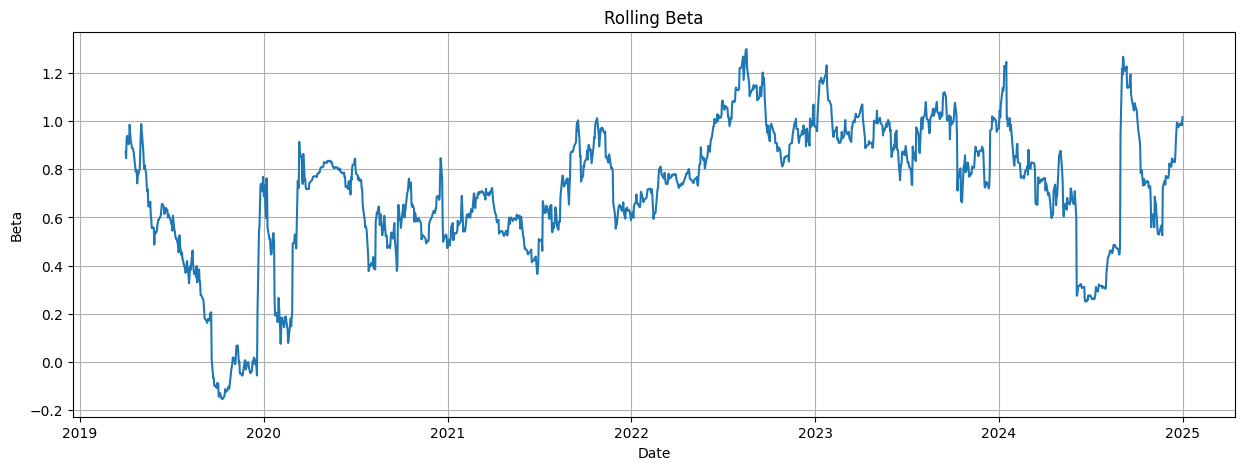

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df["Date"], df["beta"])
plt.title("Rolling Beta")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True)
plt.show()

In [ ]:
df["target"] = df["return"].shift(-1)

In [ ]:
df[["return","target"]].head(10)

,return,target
0,0.010774,-0.012141
1,-0.012141,-0.012158
2,-0.012158,0.011216
3,0.011216,-0.002292
4,-0.002292,-0.003485
5,-0.003485,0.000848
6,0.000848,-0.024357
7,-0.024357,-0.015902
8,-0.015902,0.030084
9,0.030084,0.001258


In [ ]:
df.dropna(inplace=True) #as my last row has no tomorrow kyuki ghee khtm

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1417 entries, 60 to 1476
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1417 non-null   datetime64[ns]
 1   Close          1417 non-null   float64       
 2   High           1417 non-null   float64       
 3   Low            1417 non-null   float64       
 4   Open           1417 non-null   float64       
 5   Volume         1417 non-null   int64         
 6   return         1417 non-null   float64       
 7   log_return     1417 non-null   float64       
 8   MA5            1417 non-null   float64       
 9   MA10           1417 non-null   float64       
 10  MA20           1417 non-null   float64       
 11  Volatility     1417 non-null   float64       
 12  Volume_Change  1417 non-null   float64       
 13  Volume_MA20    1417 non-null   float64       
 14  market_return  1417 non-null   float64       
 15  beta           1417 non-n

In [ ]:
df.tail()

,Date,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
1472,2024-12-23,3893.971436,3948.940268,3853.330311,3933.067536,2195338,-0.002877,-0.002882,3984.871045,4071.697339,4072.427808,0.012251,-0.466761,2310755.70,0.007035,0.974478,0.005098
1473,2024-12-24,3913.823975,3949.876666,3893.971401,3893.971401,1181886,0.005098,0.005085,3956.965332,4048.000879,4064.318274,0.012114,-0.461638,2266816.55,-0.001086,0.986705,-0.002488
1474,2024-12-26,3904.084961,3932.974026,3879.784329,3913.823778,1208464,-0.002488,-0.002491,3923.487891,4023.808105,4056.665259,0.012099,0.022488,2249290.10,0.000950,0.983655,-0.001019
1475,2024-12-27,3900.105469,3915.182141,3883.624146,3898.372975,858100,-0.001019,-0.001020,3903.438867,3996.642139,4052.917175,0.011299,-0.289925,2164267.90,0.002661,0.989639,-0.001453
1476,2024-12-30,3894.439697,3932.365256,3850.614790,3887.135698,1527169,-0.001453,-0.001454,3901.285107,3967.135083,4047.670776,0.011178,0.779710,2139755.10,-0.007076,0.982379,-0.015389


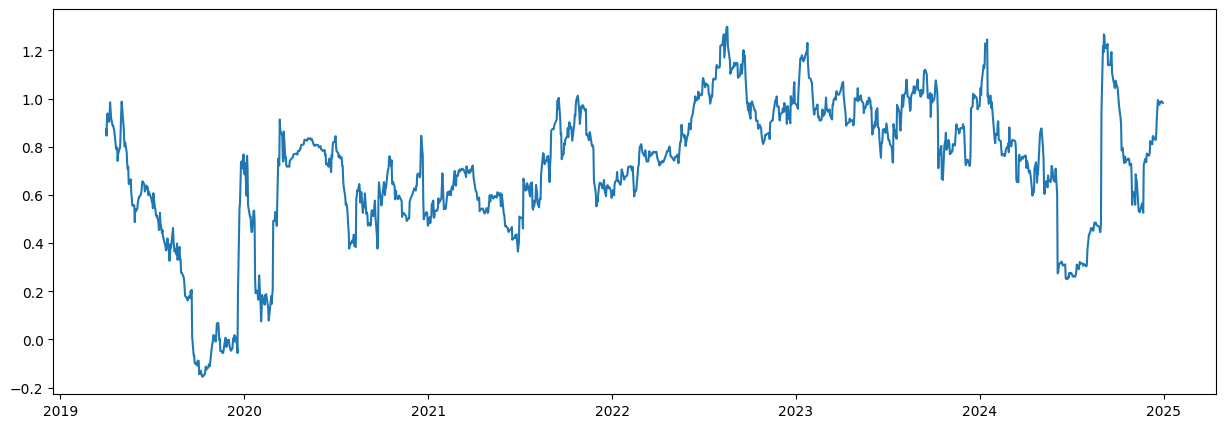

In [ ]:
plt.plot(df["Date"], df["beta"])

In [ ]:
features = ["return","log_return","MA5","MA10","MA20","Volatility","Volume_Change","Volume_MA20","market_return","beta","target"]
corr = df[features].corr()
corr

,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
return,1.000000,0.999805,-0.028083,-0.032135,-0.033690,0.017599,0.031052,0.040563,0.543053,-0.028650,-0.030687
log_return,0.999805,1.000000,-0.024857,-0.028969,-0.030615,0.009838,0.026888,0.036306,0.545308,-0.028762,-0.030147
MA5,-0.028083,-0.024857,1.000000,0.998698,0.994674,-0.374439,-0.001639,-0.483999,-0.001589,0.393507,-0.037811
MA10,-0.032135,-0.028969,0.998698,1.000000,0.997674,-0.374606,-0.001649,-0.487300,-0.005064,0.397193,-0.036610
MA20,-0.033690,-0.030615,0.994674,0.997674,1.000000,-0.374355,-0.000840,-0.494060,-0.007074,0.400686,-0.035826
Volatility,0.017599,0.009838,-0.374439,-0.374606,-0.374355,1.000000,-0.007374,0.704003,0.001925,-0.002689,0.015640
Volume_Change,0.031052,0.026888,-0.001639,-0.001649,-0.000840,-0.007374,1.000000,0.000446,-0.005138,-0.045814,0.044179
Volume_MA20,0.040563,0.036306,-0.483999,-0.487300,-0.494060,0.704003,0.000446,1.000000,0.031907,-0.305369,0.037361
market_return,0.543053,0.545308,-0.001589,-0.005064,-0.007074,0.001925,-0.005138,0.031907,1.000000,-0.016500,-0.021251
beta,-0.028650,-0.028762,0.393507,0.397193,0.400686,-0.002689,-0.045814,-0.305369,-0.016500,1.000000,-0.025941


In [ ]:
import seaborn as sns

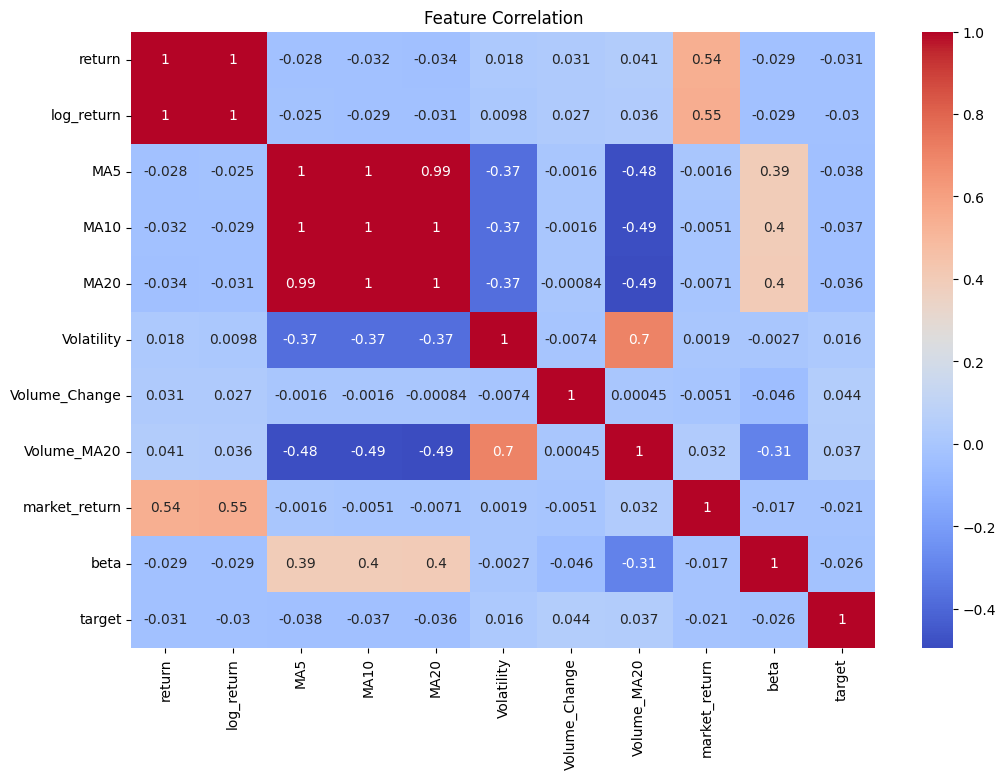

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [ ]:
import os

processed_path = "/content/drive/MyDrive/PRISM/processed"

os.makedirs(processed_path, exist_ok=True)

In [ ]:
df.to_csv(
    f"{processed_path}/TCS_processed.csv",
    index=False
)

In [ ]:
saved_df = pd.read_csv(
    f"{processed_path}/TCS_processed.csv"
)

saved_df.head()

,Date,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
0,2019-04-02,1709.451782,1714.960003,1674.675708,1674.757900,3719663,0.023454,0.023183,1654.418750,1653.493787,1651.925543,0.010694,0.774869,2817120.55,0.003775,0.872854,0.000000
1,2019-04-03,1709.451782,1717.919746,1692.022699,1714.137874,2939886,0.000000,0.000000,1670.310425,1658.138818,1655.374359,0.010672,-0.209636,2756687.45,-0.005912,0.846227,-0.031164
2,2019-04-04,1656.177979,1709.780720,1650.340886,1708.506381,4397518,-0.031164,-0.031660,1677.972656,1657.456470,1656.459564,0.012978,0.495812,2854082.25,-0.003946,0.927317,0.016778
3,2019-04-05,1683.966064,1688.980929,1659.713271,1667.811217,3152103,0.016778,0.016639,1685.865063,1660.190063,1658.461456,0.013428,-0.283209,2879935.05,0.005859,0.938799,0.010960
4,2019-04-08,1702.422729,1705.916776,1671.140697,1692.762719,2194294,0.010960,0.010901,1692.294067,1665.542102,1660.823022,0.013548,-0.303863,2862655.55,-0.005267,0.903789,0.010021


#section 13

In [ ]:
import os

raw_path = "/content/drive/MyDrive/PRISM/raw_data"
processed_path = "/content/drive/MyDrive/PRISM/processed"

os.makedirs(processed_path, exist_ok=True)

In [ ]:
nifty = pd.read_csv(f"{raw_path}/^NSEI.csv")

nifty["Date"] = pd.to_datetime(nifty["Date"])

nifty["market_return"] = nifty["Close"].pct_change()

nifty = nifty[["Date","market_return"]]

In [ ]:
files = [
    f for f in os.listdir(raw_path)
    if f.endswith(".csv")
]

In [ ]:
skip_files = [
    "^NSEI.csv",
    "NIFTY50.csv"
]
for file in files:

    # Skip market index
    if file in skip_files:
        continue

    print(f"Processing {file}")

    df = pd.read_csv(os.path.join(raw_path, file))

    # Date

    df["Date"] = pd.to_datetime(df["Date"])
    # Cleaning

    df.drop_duplicates(inplace=True)

    df.dropna(inplace=True)
    # Returns

    df["return"] = df["Close"].pct_change()

    df["log_return"] = np.log(
        df["Close"] /
        df["Close"].shift(1)
    )
    # Moving averages
    df["MA5"] = df["Close"].rolling(5).mean()

    df["MA10"] = df["Close"].rolling(10).mean()

    df["MA20"] = df["Close"].rolling(20).mean()

    # Volatility

    df["Volatility"] = (
        df["return"]
        .rolling(20)
        .std()
    )
    # Volume Features


    df["Volume_Change"] = (
        df["Volume"]
        .pct_change()
    )

    df["Volume_MA20"] = (
        df["Volume"]
        .rolling(20)
        .mean()
    )
    # Merge Market Return
    df = pd.merge(
        df,
        nifty,
        on="Date",
        how="inner"
    )
    #Beta
    covariance = (
        df["return"]
        .rolling(60)
        .cov(df["market_return"])
    )

    variance = (
        df["market_return"]
        .rolling(60)
        .var()
    )

    df["beta"] = covariance / variance
    # Target
    df["target"] = df["return"].shift(-1)
    # Remove NaNs

    df.dropna(inplace=True)
    # Save
    save_name = file.replace(".csv","_processed.csv")

    df.to_csv(
        os.path.join(processed_path,save_name),
        index=False
    )

print("All Stocks Processed Successfully!")

Processing AAVAS.NS.csv
Processing ABB.NS.csv
Processing AARTIDRUGS.NS.csv
Processing 3MINDIA.NS.csv
Processing TCS.csv
Processing ABCAPITAL.NS.csv
Processing ABBOTINDIA.NS.csv
Processing ABFRL.NS.csv
Processing ABSLAMC.NS.csv
Processing ADANIENT.NS.csv
Processing ACC.NS.csv
Processing ADANIPORTS.NS.csv
Processing ADANIGREEN.NS.csv
Processing ADANITRANS.NS.csv
Processing ADVENZYMES.NS.csv
Processing AEGISCHEM.NS.csv
Processing AFFLE.NS.csv
Processing AIAENG.NS.csv
Processing AJANTPHARM.NS.csv
Processing ALKEM.NS.csv
Processing ALKYLAMINE.NS.csv
Processing ALLCARGO.NS.csv
Processing ALOKINDS.NS.csv
Processing AMARAJABAT.NS.csv
Processing AMBER.NS.csv
Processing AMBUJACEM.NS.csv
Processing ANGELONE.NS.csv
Processing ANURAS.NS.csv
Processing APLAPOLLO.NS.csv
Processing APOLLOHOSP.NS.csv
Processing ALEMBICPHARM.NS.csv
Processing APOLLOTYRE.NS.csv
Processing APTUS.NS.csv
Processing ASAHIINDIA.NS.csv
Processing ASHOKLEY.NS.csv
Processing ASIANPAINT.NS.csv
Processing ASTRAZEN.NS.csv
Processin